# Bring Your Own Data

This notebook shows how to run TTFM inference on **your own data**. You'll learn how to prepare a DataFrame with the required columns (`t`, `y_t`, `text`), use `predict_from_dataframe()` for quick single-sample forecasting, and construct raw inputs for full control.

**Requirements:** Install the package from the repo root (`uv sync`). For live summarization a vLLM server must be running (see README); alternatively pass pre-computed `summaries` to skip LLM calls.

**See also:** [TTFM Inference Quick Start](ttfm-inference-quickstart.ipynb) for a minimal example with prepared FNSPID data.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import numpy as np
import pandas as pd
import torch
from migaseval import MigasPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline = MigasPipeline.from_pretrained("Synthefy/ttfm", device=device)
print(f"Using device: {device}")

Loading Chronos-2 on device: cuda
Loading TimesFM 2.5...
Downloaded.
Compiling model...
TimesFM 2.5 loaded
Initialized univariate models: chronos, timesfm (prophet on-demand)
Using device: cuda


## Data format

TTFM expects a DataFrame (or CSV/Parquet file) with three columns:

| Column | Type | Description |
|--------|------|-------------|
| `t` | str / datetime | Timestamp for each row |
| `y_t` | float | Target value (the time series) |
| `text` | str | Per-timestep text context (news, events, etc.). Use `""` when no text is available. |

Below we create a small synthetic DataFrame to demonstrate the workflow. Replace this with your own data.

In [2]:
np.random.seed(42)
dates = pd.date_range("2024-01-01", periods=100, freq="D")
values = np.cumsum(np.random.randn(100) * 0.5) + 100

df = pd.DataFrame({
    "t": dates.strftime("%Y-%m-%d"),
    "y_t": values,
    "text": [""] * 100,
})

# Attach text context to a few dates
df.loc[40, "text"] = "Company reports strong Q1 earnings, beating estimates by 12%."
df.loc[70, "text"] = "FDA approves new drug; analysts raise price target."

df.head()

,t,y_t,text
0,2024-01-01,100.248357,
1,2024-01-02,100.179225,
2,2024-01-03,100.503069,
3,2024-01-04,101.264584,
4,2024-01-05,101.147507,


## Quick forecast with `predict_from_dataframe`

The simplest path: pass a DataFrame and get a 1-D numpy array back.

Forecast shape: (16,)


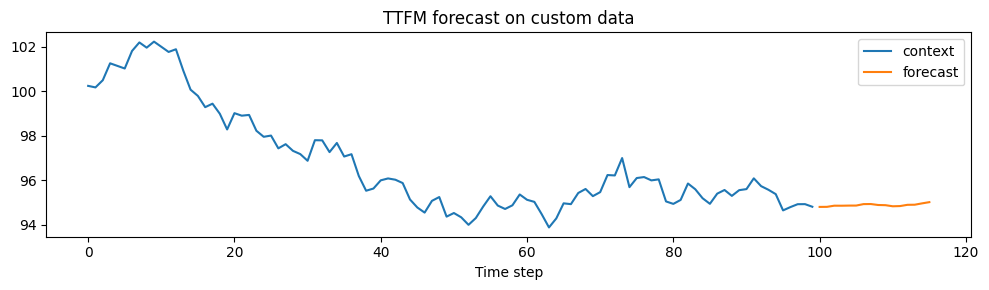

In [3]:
import matplotlib.pyplot as plt

pred_len = 16
forecast = pipeline.predict_from_dataframe(df, pred_len=pred_len)

print(f"Forecast shape: {forecast.shape}")  # (16,)

plt.figure(figsize=(10, 3))
plt.plot(df["y_t"].values, label="context")
plt.plot(np.arange(len(df), len(df) + pred_len), forecast, label="forecast")
plt.legend()
plt.xlabel("Time step")
plt.title("TTFM forecast on custom data")
plt.tight_layout()
plt.show()

## Using a subset of context

If your DataFrame is long, use `seq_len` to keep only the last N rows as context. Shorter context is faster; longer context gives the model more history.

In [4]:
forecast_short = pipeline.predict_from_dataframe(df, pred_len=16, seq_len=64)
print(f"Forecast (64-step context): {forecast_short.shape}")

Forecast (64-step context): (16,)


## Manual input construction

For full control (e.g. batching multiple samples), construct the raw `predict()` inputs yourself. The required shapes are:

- `context`: numpy array or torch tensor of shape `(B, T)`
- `text`: `List[List[str]]` — one list of T strings per sample in the batch
- `pred_len`: forecast horizon (int)

In [5]:
context = df["y_t"].values.astype(np.float32).reshape(1, -1)  # (1, 100)
text = [df["text"].fillna("").astype(str).tolist()]            # 1 x 100 strings

forecast_raw = pipeline.predict(context, text, pred_len=16)
print(f"Raw predict shape: {forecast_raw.shape}")  # torch.Size([1, 16, 1])

Raw predict shape: torch.Size([1, 16, 1])


## Loading from a CSV or Parquet file

If your data is already in a file with `t`, `y_t`, `text` columns, load it with `read_datafile` and pass the DataFrame directly.

In [6]:
from migaseval import read_datafile

# Example: load a prepared FNSPID CSV (download first: uv run python scripts/download_fnspid.py --csvs)
csv_path = "../data/fnspid_prepared/fnspid_0.5_complement_csvs/adbe_with_text.csv"
df_csv = read_datafile(csv_path)

forecast_csv = pipeline.predict_from_dataframe(df_csv, pred_len=16, seq_len=384)
print(f"Forecast from CSV: {forecast_csv.shape}")

Forecast from CSV: (16,)
